In [1]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 48.1 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...
Diagnostics:
  T range       : [-11.926392, 1.000000]
  theta range   : [0.171456, 0.259736]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.280219]
  C_app range   : [3.876987, 4.774665]
  lambda range  : [0.140898, 0.154207]
  dx = 0.050000, dt = 0.024335
  Progress: 10.0%   elapsed: 0.7s
  Progress: 20.0%   elapsed: 1.4s
  Progress: 30.0%   elapsed: 2.2s
  Progress: 40.0%   elapsed: 2.9s
  Progress: 50.0%   elapsed: 3.6s
  Progress: 60.0%   elapsed: 4.3s
  Progress: 70.0%   elapsed: 5.0s
  Progress: 80.0%   elapsed: 5.7s
  Progress: 90.0%   elapsed: 8.2s
Solution completed in 8.9s
Diagnostics:
  T range       : [-11.926392, 2.393861]
  theta range   : [0.171456, 0.270083]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.306167]
  C_app range   : [3.876987, 4.774924]
  lambda range  : [0.139338, 0.154207]
  dx = 0.050000, dt = 0.024335
Results saved to fdm_logistic_ahc_3year

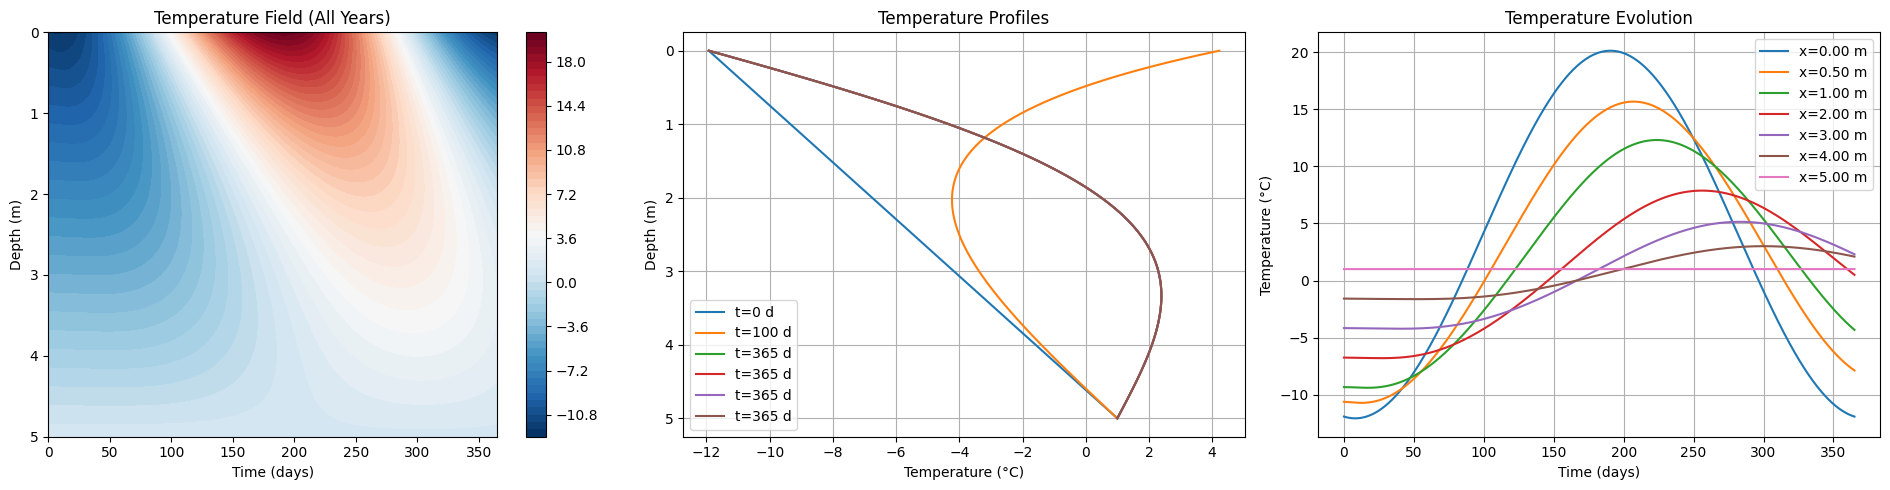

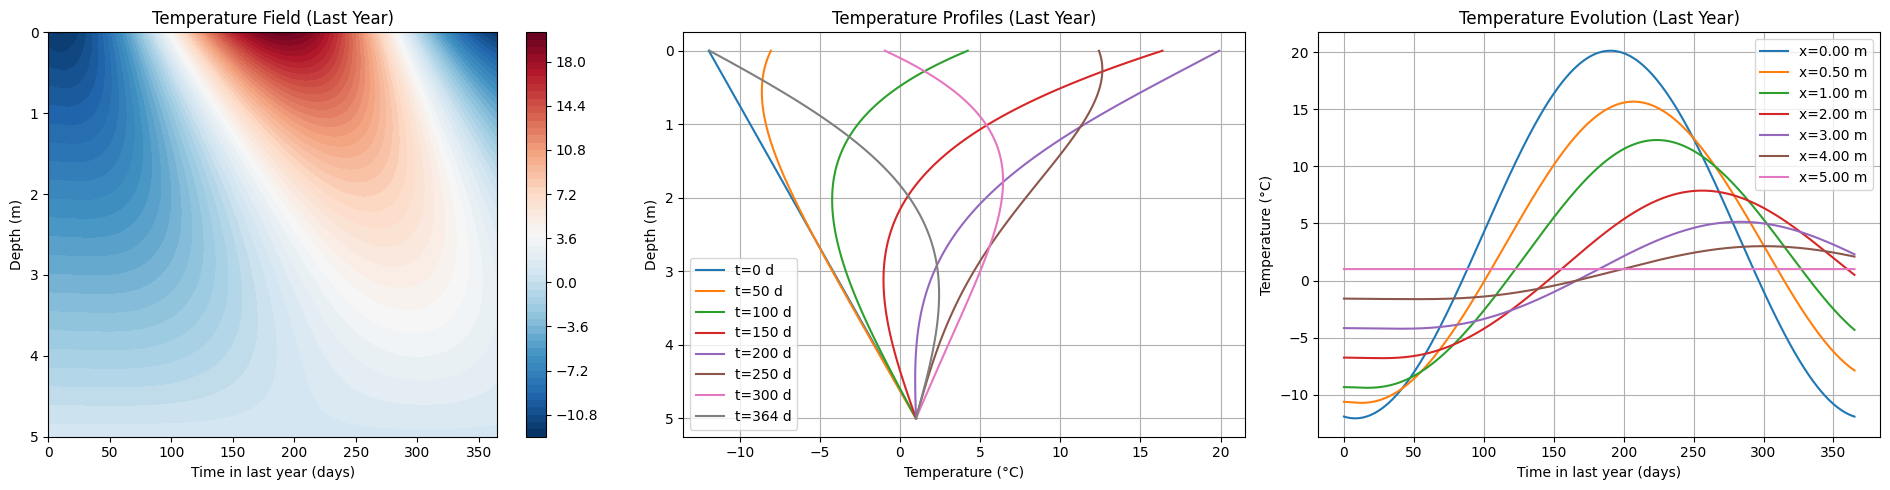

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method
    """

    def __init__(self, params):
        # ---------------------------
        # Physical parameters
        # ---------------------------
        self.L = params['L']                      # latent heat [MJ/m^3]
        self.C_i = params['C_i']                  # ice volumetric heat capacity
        self.C_l = params['C_l']                  # liquid water volumetric heat capacity
        self.C_f = params['C_f']                  # soil skeleton volumetric heat capacity

        self.lambda_i = params['lambda_i']        # ice thermal conductivity [MJ/(day·m·K)]
        self.lambda_l = params['lambda_l']        # liquid water thermal conductivity
        self.lambda_f = params['lambda_f']        # soil skeleton thermal conductivity

        self.eta = params['eta']                  # porosity / max unfrozen water content upper bound
        self.theta_r = params['theta_r']          # residual unfrozen water content
        self.T_f = params['T_f']                  # freezing transition center temperature
        self.k = params['k']                      # logistic steepness

        # ---------------------------
        # Grid parameters
        # ---------------------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature(self, t):
        """
        Surface temperature boundary condition [degC]
        You can modify this function directly if needed.
        """
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        """
        Initial temperature profile [degC]
        Linear profile from surface initial temperature to bottom temperature.
        """
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        """
        Logistic unfrozen water content:
            theta(T) = theta_r + (eta - theta_r)/(1 + exp(-k*(T - T_f)))
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        """
        Derivative of logistic unfrozen water content:
            dtheta/dT = (eta - theta_r) * k * exp(-k*(T-T_f)) / (1+exp(-k*(T-T_f)))^2
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        """
        Sensible heat capacity only:
            C_eff = (1-eta) C_f + theta C_l + (eta-theta) C_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        """
        Apparent heat capacity:
            C_app = C_eff + L * dtheta/dT
        """
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        """
        Effective conductivity:
            lambda_eff = (1-eta) lambda_f + theta lambda_l + (eta-theta) lambda_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # =========================================================
    # Initialization
    # =========================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # =========================================================
    # Diagnostics
    # =========================================================
    def print_diagnostics(self, T):
        theta = self.theta_unfrozen(T)
        dth = self.dtheta_dT(T)
        Ceff = self.effective_heat_capacity(T)
        Capp = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range       : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  theta range   : [{np.min(theta):.6f}, {np.max(theta):.6f}]")
        print(f"  dtheta/dT     : [{np.min(dth):.6f}, {np.max(dth):.6f}]")
        print(f"  C_eff range   : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  C_app range   : [{np.min(Capp):.6f}, {np.max(Capp):.6f}]")
        print(f"  lambda range  : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # =========================================================
    # Implicit solver
    # =========================================================
    def solve_implicit(self, verbose=True):
        """
        Solve:
            C_app(T) * dT/dt = d/dx( lambda(T) dT/dx )

        Backward-Euler-like implicit discretization with coefficients evaluated at old time step.
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T_old = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...")
            self.print_diagnostics(T_old)

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # ---------------------------
            # Top boundary: Dirichlet
            # ---------------------------
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_new)

            # ---------------------------
            # Bottom boundary: Dirichlet
            # ---------------------------
            A[-1, -1] = 1.0
            b[-1] = 1.0

            # ---------------------------
            # Interior nodes
            # ---------------------------
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T_old)

        return self.T_field

    # =========================================================
    # Post-processing
    # =========================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")
        t_start = self.T_total - 365.0
        mask = self.t >= t_start
        return self.t[mask] - t_start, self.T_field[:, mask]

    def save_results(self, filename="fdm_logistic_ahc_3years.npz"):
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'theta_r': self.theta_r,
                'T_f': self.T_f,
                'k': self.k
            }
        )
        print(f"Results saved to {filename}")

    def save_last_year_results(self, filename="fdm_logistic_ahc_last_year.npz"):
        t_last, T_last = self.get_last_year_data()
        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last
        )
        print(f"Last-year results saved to {filename}")

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self):
        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(self.t, self.x, self.T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (All Years)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 100, 365, 730, 900, 1094]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(self.t, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    params = {
        # latent heat and volumetric heat capacities [MJ/m^3/K or MJ/m^3]
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.60,

        # conductivities converted to MJ/(day·m·K)
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.000e-6 * 8.64e4,

        # logistic unfrozen water parameters
        'eta': 0.40,        # upper limit
        'theta_r': 0.1,    # residual unfrozen water content
        'T_f': -0.3,        # transition center [degC]
        'k': 0.1            # transition steepness
    }

    model = FreezingSoilFDM_LogisticAHC(params)

    # 3-year simulation
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 1)

    T_field = model.solve_implicit(verbose=True)

    model.save_results("fdm_logistic_ahc_3years.npz")
    model.save_last_year_results("fdm_logistic_ahc_last_year.npz")

    print("All-years T min =", np.min(T_field))
    print("All-years T max =", np.max(T_field))
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

    # Plot all years
    model.plot_results()

    # Plot last year
    model.plot_last_year_results()